# Image as Data

Introduction to Vision Modelling

## How are Images interpreted by Machines?

### What is a Digital Image?

- It is a large grid of numbers.(Matrix)
- Each number in the grid is called **Pixel.**(Smallest unit of image)

## Types of Digital Images

### Binary Image

- Contains only two values
- Each pixel is stored as 1(black) or 1(white)

### Grayscale Image

- Represents Images with shades of gray. From pure White to pure Black.
- Each pixel is a single 8-bit value from 0(black) to 255(white)

### Color Image

- Represents the full spectrum of colors by combining the different intensities of Red, Green and Blue light.
- Each pixel has three 8-bit values, one for each channel **(R,G,B)**.

## Common Computer Vision Tasks

- **Image Classification**: Assign a single label to an entire image.
- **Object Detection**: Identify objects within an image and draw bounding boxes around them.
- **Object recognition**: Detecting the object category as well as its position in the image.
- **Semantic Segmentation**: Assigning labels to each pixel ( multiple objects gets labels for them)

## Using MLP For Vision Tasks

### The Naive Approach

How can we apply an Multi-Layer Perceptron (MLP) to an Image classification task?
- We must convert 2D/3D grid into a 1D vector.

1. **Flatten the image:** Take the grid of pixels and unroll it into a single long vector.
2. **Feed into MLP:** This vector becomes the input for a standard fully connected network.

## Why MLP is not an Optimal Choice?

While technically possible, using MLPs for images is not a good idea.

Due to several Reasons:

### Massive numbers of parameters

A fully connected layers are parameter-hungry.
- A tiny 100 X 100 RGB image has:
  - 100 x 100 x 3 = 30,000 input features (pixels)
- If the first hidden layers has just 1000 neurons, this single connection requires:
  - 30,000 X 1000 = 30 million weights.
- This leads to extremely slow training, massive memory usuage, and risk of overfitting.

### Destruction of Spatial Structure

- The flattering process throws away all spatial information. The model has no idea about which pixels were originally neighbors.
- A pixel at the top left is treated same as pixel at the bottom right, even though their spatial relationship is crucial for understanding the image.

### Lack of Translational Invariance

- MLPs are not robust to object's position.
- The model learns specific weights for features at specific locations.

# Convolutional Neural Networks

Efficiently modelling the vision tasks.

## MLP To Convolution

Let's Start by thinking Multi-Layer Perceptron for images.
  
- We consider an image **X** and its hidden representation **H** as matrices of same shape.
- Let $X_{i,j}$ be the pixel at location (i,j) and $H_{i,j}$ be the corresponding hidden unit.

The Fully Connected Approach

- A fully connected layer would require a 4-th dimension weight matrix **W** to connect every input pixel to every hidden unit:

$$H_{i,j} = \sum_{k,l}W_{i,j,k,l}X_{k,l}$$

### Principle 1: Translation Invariance

We introduce a crucial inductive bias: **translation invariance**.

- This means the pattern detector should work the same regardless of where it is in the image.
- A shift in the input **X** should lead to a corresponding shift in the hidden representation **H**.

**Applying the constraint**

- This principle implies that the weights do not depend on the absolute pixel location $(i,j)$, but only on the relative offset $(k-i, l-j)$
- We can re-index the weight tensor: $W_{i,j,k,l} \to V_{k-i, l-j}$
- The layer's computation simplifies significantly:

$$H_{i,j} = \sum_{a,b}V_{a,b}X_{i+a, j+b}$$

> This is a **convolution!** The number of parameters is no longer tied to the image size, only to the size of the filter **V**.

### Principle 2: Locality

We introduce a second inductive bias: **locality**.

- To understand what's happening at location $(i,j)$, we only need to look at the pixels in its immediate vicinity.
- Information from pixels far away is less relevant.

**Applying the Constraint**

We enforce locality by setting the filter weights $V_{a,b}$ to zero outside of a small window, say $|a| > \Delta$ or $|b| > \Delta$. The computation becomes:

$$H_{i,j} = \sum_{a=-\Delta}^{\Delta} \sum_{a=-\Delta}^{\Delta} V_{a,b}X_{i+a,j+b}$$

> **The Convolutional Layer**
>
> - This equation defines a convolutional layer. The learnable tensor **V** is called the **convolution kernel** or **filter**. The number of parameters is now tiny (e.g., a few hundred) and independent of the image size

## Terminology

Let's briefly review the formal mathematical definition of convolution for 2D tensors:

### Mathematical Convolution

$$(V * X)_{i,j} = \sum_{a,b} V_{a,b}X_{i-a,j-b}$$

Notice the subtraction of indices (i-a, j-b). This involves "flipping" the kernel before sliding it over the input.

### Deep Learning "Convolution"

$$H_{i,j} = \sum_{a,b}V_{a,b}X_{i+a,j+b}$$

This is technically a **cross-correlation**.

> **The Difference in formulations**
>
> - The term **convolution** in deep learning has a different mathematical definition than in pure mathematics. What we use is technically called **cross-correlation**.
> - **Does it matter?** Not really. Since the kernel V is learned during training, the network can simply learn the flipped version of the kernel if needed. The terms are used interchangeably in deep learning.


## Channels

Real world images aren't 2D; they are 3rd-order tensors with color channels (e.g., Red, Green, Blue).

- Input **X** has shape: (height, width, **input channels**).
- We also want our hidden representations **H** to have multiple channels, often called **feature maps**. Each map can learn to detect a different feature.
- Hidden Representation **H** has shape: (height, width, **output channels**).

### The General Convolutional Layer

Our kernel **W** becomes a 4th- order tensor, mapping from input channels to output channels. Let $c_i$ be the input channel index and $c_o$ be the output channel index. The full equation for a convolutional layer is:

$$H_{i,j,c_o} = \sum_{c_i} \sum_{a,b} W_{a,b,c_i, c_o} X_{i+a, j+b, c_i} + bias_{c_o}$$

## The Convolutional Layer in CNNs

The **convolution layer** is the core building block of a CNN. It performs the convolution operation.

### Key Components

- **Input:** A matrix of pixel values (e.g, a grayscale image). For a color image, this is a 3D tensor with dimensions (height, width, channels).
- **Filter (or Kernel):** A small matrix of learnable weights. This filter slides or "convolves" across the input data.
- **Feature Map (or Activation Map)**: The output of the convolution. It represents the "Activations" or responses of the filter at every spatial position of the input.

> Key Note
>
> - The convolution operation involves an element-wise multiplication of the filter with a portion of the input, followed by a summation.

## Learning a Convolutional Kernel

### How does the Network learn?

- The filter weights are initialized randomly: $W \sim N(0, \sigma^2)$
- During training, the network makes a prediction. 

$$\hat{y} = f_W(X)$$

- The error (loss) between the prediction and the true label is calculated.

$$L = \frac{1}{N} \sum_{i=1}^N (y_i-\hat{y}_i)^2$$

- Using **backpropagation** and **gradient descent**, the filter weights are adjusted slightly to minimize the error.
  - The below process is repeated for every image and for multiple iterations till the loss converges.

$$W \leftarrow W - \eta \frac{\partial L}{\partial W}$$

> **Outcome**
>
> - Over many iterations, the filters evolve to detect features (edges, colors, textures, patterns) that are most useful for the specific task (e.g., classifying cats vs dogs).

## Feature Maps

- A feature map is the ouput of one convolutional filter applied to the input.
- Since a convolutional layer typically has many filters, its full output is a 3D volume where each 2D slice is a feature map for a specific feature.
- For example, one map might activate for vertical edges, another for green patches, and a third for a specific texture.

## Receptive Field & Kernel Size

- The receptive field of a neuron id the size of the region in the original input image that affects its activation.
- In the first conv layer, the receptive field is just the filter size (e.g., 3 X 3)
- As we stack more convolutional layers, the receptive field size grows. A neuron in Layer 2 is looking at neurons from layer 1, which in turn look at the input image.

## Hierachical Learning

### Key Details about Receptive Field

This allows the network to build a **hierarchy of features**:

- Layer 1 learns simple edges from pixels
- Layer 2 learns corners and contours from edges
- Layer 3 learns parts of objects (like an eye or a nose) from corners
- Deeper layers learn to recognize entire objects.

# Hyperparameters of CNNs

## Kernel Size

- The kernel size (or filter size) defines the dimensions (height X width) of the convolutional window that slides over the input data.
- It determines the size of the **receptive field** - the area of the input that the filter considers to compute a single value in the output feature map.

### Common Choices

- **3 X 3**: The most widely used size. Stacking multiple 3 X 3 layers can capture a larger receptive field with fewer parameters and more non-linearlity than one large kernel.
- **5 X 5, 7 X 7**: Used to capture larger spatial patterns, often in the initial layers of a network.
- A smaller kernel has a smaller receptive field, focusing on local details.

### Trade-off

Smaller kernels learn local, fine-grained features, while larger kernels capture more global, coarse features at a higher computational cost.

## Importance of 1 X 1 Convolutions

### What is 1 X 1 convolution?

- A convolution with a 1 X 1 kernel might seem strange - it only looks at one pixel at a time! However, it is a very powerful technique, also known as a "Network in Network" layer.

**Use Case 1: Dimensionality Reduction**

- Imagine an input volume of $56 \times 56 \times 192$.
- Applying 32 filters of size 1 X 1 X 192 results in an output volume of 56 X 56 X 32
- We have reduced the number of channels (the depth) from 192 to 32 without changing the spatial dimensions(height and width).

**Use Case 2: Adding Non-Linearity**

- A $1 \times 1$ convolution is essentially a fully connected layer operating on the channel dimension for each pixel.
- By applying a non-linear activation function (like ReLU) after the 1 X 1 convolution, the network can learn more complex relationships between channels.
- This increases the model's expressive power without affecting its receptive field.

## Stride

- **Stride** defines the step size, or the number of pixels the convolutional kernel moves over the input feature map at a time.
- A stride of 1 $(S=1)$ means the kernel shifts one pixel at a time (horizontally or vertically). This is the most common setting.

### Primary Effect: Downsampling

- Usign a stride greater than 1 reduces the spatial dimensions (height and width) of the output feature map.
- This is often used in place of pooling layers to decrease the computational load and help the network learn more abstract representations by reducing spatial resolution.

## Strided Convolution Illustration

Input Feature Map (5 X 5)

![Screenshot From 2026-04-26 23-58-39.png](<attachment:Screenshot From 2026-04-26 23-58-39.png>)

3 X 3 Kernel, Stride = 2

![Screenshot From 2026-04-26 23-59-54.png](<attachment:Screenshot From 2026-04-26 23-59-54.png>)

Output Feature Map (2 X 2)

![Screenshot From 2026-04-27 00-00-25.png](<attachment:Screenshot From 2026-04-27 00-00-25.png>)

Instructions:

- Position kernel at (0,0) -> compute $y_{0,0}$
- Move kernel by stride = 2 to (0,2) -> compute $y_{0,1}$
- Move kernel to (2,0) -> compute $y_{1,0}$
- Move kernel to (2,2) -> compute $y_{1,1}$

## Stride and Output Size calculation

For a convolutional operation:

**Output Size formula:**

$$\text{Output Size} = \left\lfloor \frac{\text{Input Size} - \text{Kernel size}}{\text{Stride}} \right\rfloor  + 1$$

**Examples**

- Stride 1 : $\left\lfloor \frac{4-3}{1} \right\rfloor + 1 = 2$
- Stride 2 : $\left\lfloor \frac{4-3}{2} \right\rfloor + 1 = 2$

> Note: This assumes no padding


## Padding

**Padding** is the process of adding extra pixels (usually with a value of 0, called zero-padding) around the border of an input feature map.

### Why use Padding?

- **To control the output size.** Without padding, the spatial dimensions shrink with each convolution. Padding allows us to preserve the input dimensions.
  - "Same" Padding: Adds enough padding to make  the output feature map have the same height and width as the input.
  - "Valid" Padding: No padding is applied. The output is smaller than the input
- **To improve performance at the borders.** Pixels at the edges of an image are seen by the kernel fewer times  than central pixels. Padding ensures that edge and corner pixels are gives more considerations during convolution.

## Convolution Layer Output

The size of the output feature map is controlled by three key hyperparameters:

- **Kernel Size (K)**: The dimensions of the filter (e.g., 3 X 3, 5 X 5).
- **Stride (S)**: The Number of pixels the filter moves at each step. A stride of 1 moves one pixel at a time, while a stride of 2 skips a pixel.
- **Padding (P):** Adding zeros around the border of the input image. This allows us to control the output size and helps keep information at the borders.

### Output Size Formula
For an input of width W and height H, the output dimensions $(W_{out}, H_{out}, C_{out})$ are:

$$W_{out} = \frac{W-K+2P}{S} + 1$$

$$H_{out} = \frac{H-K+2P}{S} + 1$$

$C_{out}$ = Number of convolution Filter

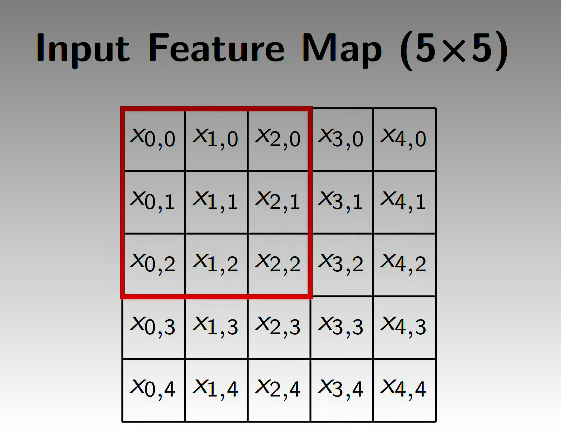
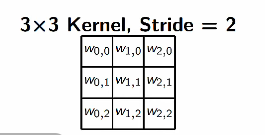
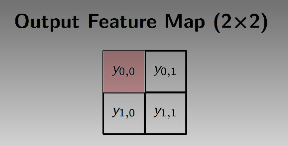

# Other Components of CNNs

## Pooling Layer

A pooling layer performs non-linear **downsampling** to reduce the spatial dimensions (width and height) of the feature maps.

### Key Purposes

- **Reduce Computational Cost:** Decreases the number of parameters and computations in the network by making feature maps smaller.
- **Increase Receptive Field:** Allows subsequent convolutional layers to see a larger area of the original input.
- **Provide Translational Invariance:** Makes the network more robust to small shifts and distortions in the input image. The output of the pooling operation can remain the same even if the input features move slightly.

## Types of Pooling Layers

### Max Pooling

- Selects the **maximum** value from each patch.
- Most common type.
- Effective at capturing the most prominent features.

### Average Pooling

- Computes the average value from each patch.
- Smooths the feature representation

## Illustration of Pooling Layers

Applying a 2 X 2 pooling operation with a stride of 2.

### Max Pooling

![Screenshot From 2026-04-27 00-59-21.png](<attachment:Screenshot From 2026-04-27 00-59-21.png>)



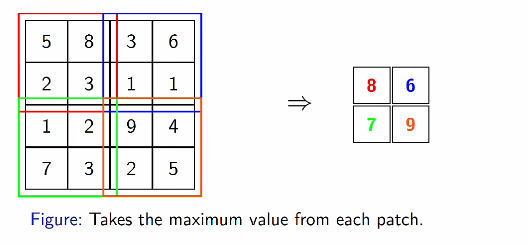